<div style="text-align: left;">
    <img src="../images/Virtuelle_Hochschule_Bayern_logo.svg" alt="ZenBite Picture" style="width: 20%; max-width: 20%; margin-top: 30px; margin-bottom: 20px; float: left;">
    <div style="clear: both;"></div>
</div>

<div class='bar_title'></div>

<span style="color: #E59635; font-size: 56px;">Data-Driven Supply Chain Management</span>

## Session 2a - Assignment 

<br>

<span style="color: #7F7F7F;">*Data-Driven Decisions Group (D3)*</span>

## Import Libraries

In [30]:
from dscm.session2 import *
from ddop2.metrics import average_costs
import numpy as np
from dscm.submit import *

In [31]:
# Just for better display of the graphs

from IPython.display import display, Javascript

disable_autoscroll_js = """
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}
"""

display(Javascript(disable_autoscroll_js))

<IPython.core.display.Javascript object>

Import the dataset from the ddop package 

In [32]:
zenbite = load_zenbite()

Now let us take a look at our past demands:

In [33]:
zenbite.target

,salmon,beef,prawns,pork,crabs,duck,chicken
0,7,7,13,46,26,58,41
1,10,10,6,50,41,42,34
2,10,8,16,29,18,34,24
3,4,4,2,26,12,26,21
4,7,4,9,21,17,27,27
...,...,...,...,...,...,...,...
710,4,4,8,28,34,42,15
711,7,4,10,42,25,37,23
712,5,7,8,32,37,45,18
713,4,4,7,43,43,51,23


In the lecture we analysed the demand data for chicken. 

In [34]:
demand_chicken = zenbite.target['chicken']

Now let's take a look at another product: `salmon`.

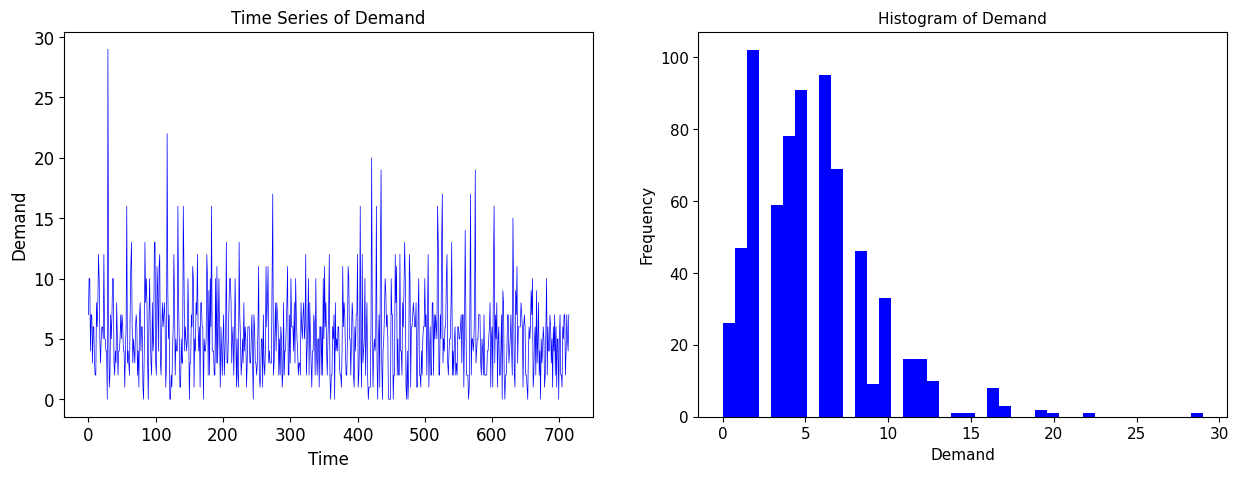

In [35]:
# get the demand of the right ingredient 
demand_salmon = zenbite.target["salmon"]


# plot the chicken demand
plot_time_series_and_hist(demand_salmon)

## Task 1 Analyze the demand for salmon
* Divide the historic demand data into two parts: training and test data. Use the first 500 days as training data and the rest as test data.




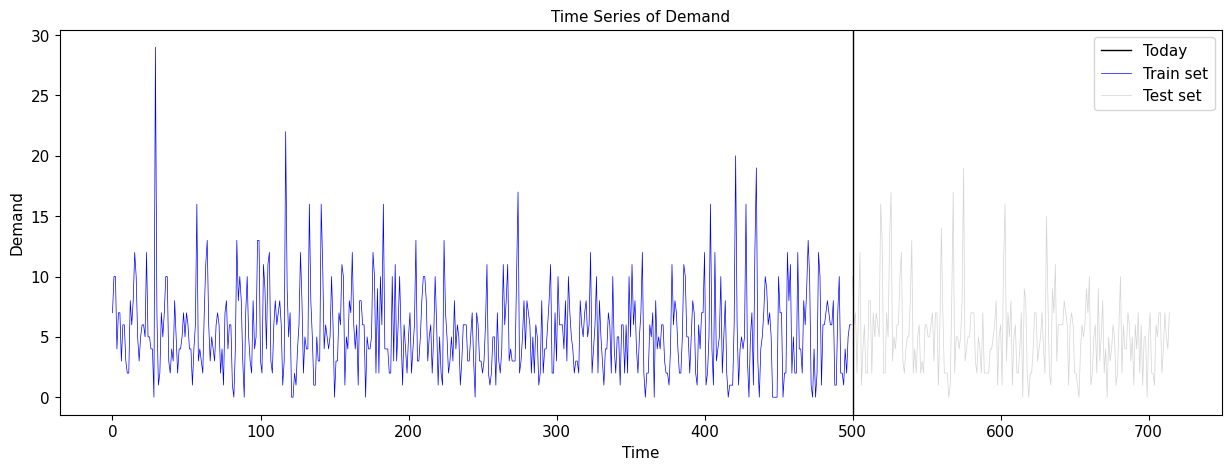

In [36]:
plot_time_series_split(demand_salmon) 
train = range(500)
test = range(500,715)

### Question 1.1: What is the average demand for salmon in the training data? What is the standard deviation of the demand in the training data?

Tip: You can use the `np.mean()` and `np.std()` functions from the `numpy` library.


In [37]:
q_avg = np.mean(demand_salmon[train])
print("The average quantity demand in the first 500 days is:", q_avg)
std_demand = np.std(demand_salmon[train])
print("Standard deviation:", std_demand)


The average quantity demand in the first 500 days is: 5.458
Standard deviation: 3.7078613782071197


 # Interpretation
 As we can see from the graph, the average demand for salmon is around 5 units. The calculated mean (≈ 5.46) confirms this observation. However, there are some demand spikes, for example in the first 100 days, where demand is significantly higher than usual. This indicates that the demand is not perfectly stable and shows variability (uncertainty). Therefore, the mean demand can be used as a baseline for decision-making, but it may not always be optimal since actual demand can fluctuate.

#### Submit your answer to Question 1.1
* Tip: Use `submit_answer_to_question11` function to submit your answer.
Set the `mean_demand` and `std_demand` variables to the mean and standard deviation of the demand for salmon that you calculated in the previous cell.


In [38]:
mean_demand = np.mean(demand_salmon[train])
std_demand = np.std(demand_salmon[train])
submit_answer_to_question11(mean_demand, std_demand)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


### Question 1.2: Compare the average demand and the standard deviation of the demand for salmon with the demand for chicken.


* Which product has higher average demand? Which product has higher demand variation?

* Tip You can use the Coefficient of Variation (CV) to compare the demand variation of the two products. The CV is defined as the ratio of the standard deviation to the mean: $CV = \frac{\sigma}{\mu}$.

In [39]:
mean_salmon = mean_demand
std_salmon = std_demand

demand_chicken = zenbite.target["chicken"]
mean_chicken = np.mean(demand_chicken[train])
std_chicken = np.std(demand_chicken[train])

cv_salmmon = std_salmon / mean_salmon
cv_chicken = std_chicken / mean_chicken

print("Salmon mean:", mean_salmon)
print("Chicken mean:", mean_chicken)
print("Salmon CV:", cv_salmmon)
print("Chicken CV:", cv_chicken)

Salmon mean: 5.458
Chicken mean: 28.094
Salmon CV: 0.6793443345927298
Chicken CV: 0.4782238565298551


In [40]:
product_with_higher_demand = "salmon" if mean_salmon > mean_chicken else "chicken"
product_with_higher_variation = "salmon" if cv_salmmon > cv_chicken else "chicken"
print(product_with_higher_demand)
print(product_with_higher_variation)

chicken
salmon


# Interpretation
Chicken has a significantly higher average demand than salmon, indicating that it is sold more frequently. However, salmon has a higher CV, which means that it's demand is more volatile and uncertain relative to it's mean. This implies that salmon is more difficult to forecast and manage in terms of inventory, while chicken demand is more stabile despite it's higher volume.

Submit your answer to Question 1.2
* Tip: you can use the `submit_answer_to_question12` function to submit your answer. Set the `product_with_higher_demand` and `product_with_higher_variation` variables to the product with higher average demand and the product with higher demand variation, respectively. Type in `salmon` or `chicken` for each variable.

In [41]:
product_with_higher_demand ="chicken"
product_with_higher_variation = "salmon"

submit_answer_to_question12(product_with_higher_demand,
                            product_with_higher_variation)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


**Now assume that the overage costs and the underage costs are both higher for salmon than for chicken as it is more expensive**

In [42]:
cu = 20
co = 10

## Task 2: Calculate the optimal order quantity for salmon

### Question 2.1 Calculate the average costs for ordering the average demand of salmon on the test data.
* Tip: 
1. Create a numpy array and fill it with the average demand of salmon in the test data. You can use the `np.full()` function from the `numpy` library.
2. Calculate the average costs for ordering the average demand of salmon on the test data. You can use the `average_costs()` function from the `ddop` package.

In [43]:
pred_test = np.full(len(test), mean_demand)
avg_cost = average_costs(demand_salmon[test], pred_test, co=co, cu=cu)
print("The resulting average costs:", np.round(avg_cost, 2))

The resulting average costs: 36.84


# Interpretation
We use the mean as a constant ordering strategy. The resulting average cost of 36.84 shows that this simple strategy leads to significant costs due to demand uncertainty. Since demand fluctuates, ordering the mean results in both underage and overage costs.
In this case, the underage cost, cu = 20, is twice as high as the overage cost, co = 10. This means that not serving a customer is much more expensive than having excess inventory. Therefore, it is more important to satisfy demand and avoid stockouts.
This has a strong impact on the performance of the ordering strategy. Overall, this explains why a simple mean based approach may not be optimal, and why we may prefer ordering slightly more than the average demand.

Submit your answer to Question 2.1

* Tip: Use the `submit_answer_to_question21` function to submit your answer. Set the `cost_avg` variable to the average costs for ordering the average demand of salmon.

In [44]:
cost_avg = avg_cost
submit_answer_to_questio21(cost_avg)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


### Question 2.2  What is the optimal order quantity for salmon?

* Tip: Try out different order quantities and calculate the average costs for each order quantity. Therefore, you can use the `average_costs` function from the `ddop` package.



#### Try out and compare the average costs for the following order quantities: 

* Two units less than the average demand of salmon
* One unit less than the average demand of salmon
* The average demand of salmon
* One unit more than the average demand of salmon
* Two units more than the average demand of salmon

In [45]:
# Two units less than the average demand of salmon
q_minus_2 = mean_demand - 2

pred_test = np.full(len(test), q_minus_2)

avg_cost_minus_2 = average_costs(
    demand_salmon[test],
    pred_test,
    co=co,
    cu=cu
)

print("Average cost:", np.round(avg_cost_minus_2, 2))

Average cost: 50.77


In [46]:
# One unit less than the average demand of salmon
q_minus_1 = mean_demand - 1

pred_test = np.full(len(test), q_minus_1)

avg_cost_minus_1 = average_costs(
    demand_salmon[test],
    pred_test,
    co=co,
    cu=cu
)

print("Average cost:", np.round(avg_cost_minus_1, 2))

Average cost: 42.02


In [18]:
# The average demand of salmon
q_avg = mean_demand

pred_test = np.full(len(test), q_avg)

avg_cost_avg = average_costs(
    demand_salmon[test],
    pred_test,
    co=co,
    cu=cu
)

print("Average cost:", np.round(avg_cost_avg, 2))

Average cost: 36.84


In [19]:
# One unit more than the average demand of salmon
q_plus_1 = mean_demand + 1

pred_test = np.full(len(test), q_plus_1)

avg_cost_plus_1 = average_costs(
    demand_salmon[test],
    pred_test,
    co=co,
    cu=cu
)

print("Average cost:", np.round(avg_cost_plus_1, 2))

Average cost: 35.92


In [20]:
#Two units more than the average demand of salmon
# Two units more than the average demand of salmon
q_plus_2 = mean_demand + 2

pred_test = np.full(len(test), q_plus_2)

avg_cost_plus_2 = average_costs(
    demand_salmon[test],
    pred_test,
    co=co,
    cu=cu
)

print("Average cost:", np.round(avg_cost_plus_2, 2))

Average cost: 39.12


# Interpretation
We compare different order quantities around the mean demand. The lowest average cost is achieved when ordering one unit more than the mean demand. This result makes sense because the underage cost is higher than the overage cost, so avoiding stockouts is more important than avoiding excess inventory.

Submit your answer to Question 2.2

* Tip: Use the `submit_answer_to_question22` function to submit your answer. Set the `optimal_order_quantity` variable to the optimal order quantity for salmon.

In [21]:
optimal_order_quantity = int(round(mean_demand + 1))

submit_answer_to_question22(optimal_order_quantity)

The answer has been saved locally. Please submit the assignment when you are done with all questions.
